# Macro Data - Linear State-Space Models

This notebook fits linear Gaussian state-space models (LG-SSMs) to US macroeconomic data from FRED
and compares filtering/smoothing performance across model specifications.

Models (in increasing complexity):
1. **Simple LG-SSM** — 1D latent state, 1D observation (GDP growth). Suffers from weak-identifiability of `alpha`; fix `alpha = 1`.
2. **Multivariate Observation LG-SSM** — 1D latent "business cycle" state, K=3 quarterly observations (GDP growth, IP growth, −ΔUR). Identification via reference series (`alpha_1 ≡ 1`).
3. **Macro LG-SSM** — Structural macro model with 6D latent state (output gap, potential growth, NAIRU, expected inflation, neutral rate, lagged output gap) and 4 observed series. See `linear_macro.py`. **[Not yet implemented]**
4. *(Extra)* **Free multivariate LG-SSM** — Obs and latent dims specified, but all entries of `A`, `C`, intercepts left free. Will likely suffer from weak-identifiability.

## Description of the Models

### Simple LG-SSM

$$
\begin{align}
& x_t = \phi x_{t-1} + \epsilon_t,
&& \epsilon_t \sim N(0, \sigma^2) \\
& y_t = \alpha x_t + \nu_t,
&& \nu_t \sim N(0,\tau^2)
\end{align}
$$

Parameterized by $\theta = (\phi, \sigma^2, \tau^2)$ with $\alpha \equiv 1$ fixed.

**Weak-identifiability:** Without fixing $\alpha$, the likelihood is invariant under the scaling $(x_t, \alpha) \mapsto (x_t / c, \alpha c)$ for any $c > 0$. Fixing $\alpha = 1$ resolves this. Note that even with $\alpha = 1$, $\sigma^2$ and $\tau^2$ are separately identified only through the time-series autocorrelation structure.

**Initial distribution:** Stationary, $x_0 \sim N\!\left(0,\, \sigma^2 / (1 - \phi^2)\right)$.

**Estimation:** Exact log-likelihood via scalar Kalman filter recursion (see `SimpleLinearGaussianSSM.log_likelihood`). MLE via L-BFGS-B in the unconstrained space $(\text{arctanh}(\phi),\, \log\sigma^2,\, \log\tau^2)$

### Multivariate Observation LG-SSM

$$
\begin{align}
& x_t = \phi x_{t-1} + \epsilon_t,
&& \epsilon_t \sim N(0, \sigma^2) \\
& y_t^{(k)} = \alpha^{(k)} x_t + \nu_t^{(k)},
&& \nu_t^{(k)} \sim N(0, (\tau^{(k)})^2), \quad k = 1, \ldots, K
\end{align}
$$

Parameterized by $\theta = \bigl(\phi, \sigma^2, \{ \alpha^{(k)}, (\tau^{(k)})^2 \}_{k=1}^{K}\bigr)$.

**Identification:** Fix $\alpha^{(1)} \equiv 1$ (GDP growth as the reference series). The latent state $x_t$ is then interpreted as a common business cycle factor.

**Intercepts:** Assuming all series are demeaned and standardized before fitting, the intercepts $\mu^{(k)}$ are not needed (they would be estimated at zero).

**Observations used (K = 3):**
1. **Real GDP growth** — $100 \times \Delta \log \texttt{GDPC1}$ (quarterly); $\alpha^{(1)} \equiv 1$ (reference)
2. **Industrial production growth** — $100 \times \Delta \log \texttt{INDPRO}$, quarter-end
3. **Negative unemployment-rate change** — $-\Delta\texttt{UNRATE}$, quarter-end (sign-flipped to be procyclical)

**Estimation:** Exact log-likelihood via multivariate Kalman filter (`LinearGaussianSSM.log_likelihood`).

### Macro LG-SSM (HLW)

See `src/models/linear_macro.py` and `src/models/linear_macro_model.md` for the full specification.

8D latent state $s_t = [x_t, x_{t-1}, g_t^*, \zeta_t, r_t^*, r_{t-1}^*, u_t^*, u_{t-1}^*]$,
4 observed series $(\Delta Y_t, \pi_t, u_t, i_t)$ in annualised percent.

$$
\begin{align}
x_t &= \phi_1 x_{t-1} + \phi_2 x_{t-2} + \lambda_r\tfrac{(r_{t-1}-r_{t-1}^*)+(r_{t-2}-r_{t-2}^*)}{2} + \varepsilon_{x,t} && \text{IS curve, } \lambda_r < 0 \\
g_t^* &= g_{t-1}^* + \varepsilon_{g,t} && \text{trend growth}\\
\zeta_t &= \zeta_{t-1} + \varepsilon_{\zeta,t} && \text{persistent non-growth component of }r_t^*\\
r_t^* &= c_g g_t^* + \zeta_t && \text{neutral real rate (no own shock)}\\
u_t^* &= u_{t-1}^* + \varepsilon_{u^*,t} && \text{NAIRU}
\end{align}
$$

$$
\begin{align}
\Delta Y_t &= g_t^* + (x_t - x_{t-1}) + \varepsilon_{\Delta Y,t} \\
\pi_t &= \alpha_\pi \pi_{t-1} + (1-\alpha_\pi)\bar\pi_{t-2:4} - \beta_\pi(u_{t-1}-u_{t-1}^*) + \varepsilon_{\pi,t} \\
u_t &= u_t^* - \gamma x_t + \varepsilon_{u,t} \\
i_t &= \rho_i i_{t-1} + (1-\rho_i)[r_t^* + \pi^* + \psi_\pi(\tilde\pi_t - \pi^*) + \psi_x x_t] + \varepsilon_{i,t}
\end{align}
$$

**Identification note.** $\sigma_g$, $\sigma_\zeta$, and $c_g$ are weakly identified (HLW identification problem): the level of $r_t^*$ depends on two independent random walks driven by $\varepsilon_g$ and $\varepsilon_\zeta$, and the data give little information to separate them. These three parameters are **fixed** during MLE; the remaining 15 are estimated freely.

In [10]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Section 1: Data Import and Exploration

Data is downloaded from FRED via `data/macro_data_download.py` and cached to CSV on first run.
All series are aligned to a **quarterly** index (quarter-end dates). Monthly series (INDPRO, UNRATE)
are sampled at the last observation of each quarter before differencing.

**Standardization:** `build_multivariate` returns each series **demeaned and divided by its
sample standard deviation** (z-score over the full sample). This makes the three series
comparable on a common scale and simplifies model parameterization (see intercept discussion above).

> **[WARNING]** For simplicity, this notebook uses the full sample to perform standardization. This **leaks future information**, which will distort results for forward-looking tasks such as prediction. This is fine if the task is only backwards-looking, for example smoothing.

**Steps:**
1. Load (or re-download) raw FRED data and build the multivariate panel
2. Inspect shape, date range, and pairwise correlations
3. Plot raw standardized series
4. Inspect ACF/PACF of each series
5. Fit ARMA(p,q) benchmarks (`src/time_series_analysis.py`) to check for serial correlation structure that the latent factor should capture

In [11]:
import sys
from pathlib import Path

# Project root in sys.path → lets us import from data/
# src/ in sys.path → lets us import models/, estimation/, utils directly
# (source files use bare `from utils import ...`, `from models.base import ...`, etc.)
_project_root = Path("..").resolve()
_src = _project_root / "src"
for _p in [str(_project_root), str(_src)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from data.macro_data_download import download_raw, build_univariate, build_multivariate

DATA_DIR = Path("../data")

_CACHE_FILES = ["fred_raw.csv", "univariate.csv", "multivariate.csv"]

if all((DATA_DIR / f).exists() for f in _CACHE_FILES):
    _fred_raw = pd.read_csv(DATA_DIR / "fred_raw.csv",
                            index_col="observation_date", parse_dates=True)
    _raw = {col: _fred_raw[col].dropna() for col in _fred_raw.columns}
    print("Loaded from cache.")
else:
    _raw = download_raw()

Loaded from cache.


In [12]:
Y_std_mv = build_multivariate(_raw) # already standarized

Y_arr_mv    = Y_std_mv.values
T_mv, d_obs = Y_arr_mv.shape
dates_mv    = Y_std_mv.index

print(f"Data matrix Y_arr_mv: {Y_arr_mv.shape}")
print(f"Range: {dates_mv[0].date()} \u2192 {dates_mv[-1].date()}")
print()
print("Correlations across series:")
print(Y_std_mv.corr().round(3))

Data matrix Y_arr_mv: (312, 3)
Range: 1948-04-01 → 2026-01-01

Correlations across series:
             GDP_growth  IP_growth  neg_UR_diff
GDP_growth        1.000      0.669        0.774
IP_growth         0.669      1.000        0.616
neg_UR_diff       0.774      0.616        1.000


<Axes: xlabel='observation_date'>

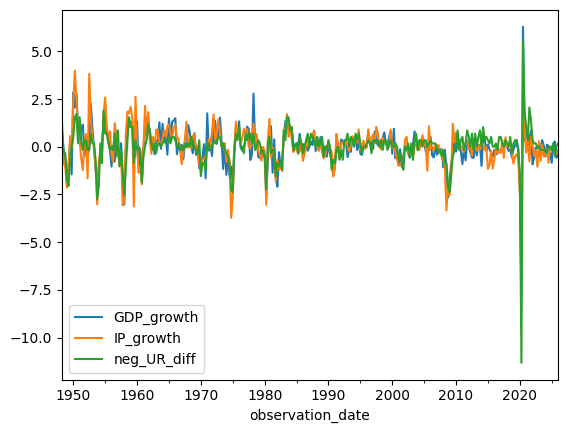

In [13]:
Y_std_mv.plot()

# Section 2: Models and Parameter Estimation

**Approach:** Use `MLEEstimator`, which wraps `scipy.optimize.minimize` in the *unconstrained* parameter
space. The model's `unconstrain_params` / `constrain_params` methods handle the reparameterization
(e.g. $\phi \mapsto \text{arctanh}(\phi)$, $\sigma^2 \mapsto \log\sigma^2$). Multiple random restarts
reduce the risk of converging to a local optimum.

**Fixing parameters:** `MLEEstimator.fit(fixed_params={'alpha': 1.0})` holds `alpha` at its
constrained value throughout optimization. Internally, `fit` operates over only the free-parameter
subspace and the stored `alpha` unconstrained coordinate is spliced back in before every likelihood
evaluation. Fixed parameters receive `NaN` standard errors in the summary.

**Standard errors** are computed via `mle_estimator.compute_std_errors()`, which applies the delta
method to a numerical Hessian over the *free* parameters only.

**Steps:**
1. Instantiate each model with reasonable initial parameters; call `.describe()` to confirm setup
2. Run `MLEEstimator.fit(fixed_params=...)` for each model; inspect convergence and log-likelihood
3. Compute and display standard errors via `.compute_std_errors()`
4. Plot the MLE parameter estimates across models

In [14]:
from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM
from models.linear_factor import MultivariateObservationLGSSM
from models.linear_macro import LinearMacroSSM
from estimation.mle_estimator import MLEResult, MLEEstimator

In [15]:
gdp_growth = Y_std_mv['GDP_growth'].values  # standardized GDP growth series as np array

SimpleLGSSM = SimpleLinearGaussianSSM(phi=0.5, alpha=1.0, sigma2=1.0, tau2=0.5, seed=42)
print(SimpleLGSSM.describe())

mle_simple = MLEEstimator(
    model=SimpleLGSSM,
    data=gdp_growth,
    method="L-BFGS-B",
    n_restarts=20,
    restart_std=0.5,
    seed=10,
)

# alpha is fixed at 1 to resolve the scale weak-identifiability.
# SE for alpha will be NaN (it was not estimated).
result_simple = mle_simple.fit(fixed_params={'alpha': 1.0})
mle_simple.compute_std_errors()
print(result_simple.summary())

SimpleLinearGaussianSSM
  Simple linear Gaussian SSM — 1D latent state and observation
  Parameters: {'phi': 0.5, 'alpha': 1.0, 'sigma2': 1.0, 'tau2': 0.5}
  Transition:  x_t = 0.5 * x_(t-1) + eps_t,   eps_t ~ N(0, 1.0)
  Observation: y_t = 1.0 * x_t + nu_t,       nu_t  ~ N(0, 0.5)
  Initial:     x_0 ~ N(0, 1.33333)  [stationary]
MLEEstimator.fit  1.749s
MLEResult  loglik=-438.6789  converged  n_evals=112
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.457593      0.205961
  alpha                 1.000000             —
  sigma2                0.243733      0.192078
  tau2                  0.688374      0.183839


In [16]:
phi_s_hat, alpha_s_hat, sigma2_s_hat, tau2_s_hat = result_simple.constrained_params

## 2.2 Multivariate Observation LG-SSM

Fit a single latent business-cycle factor to all three standardized series jointly.
The identification constraint $\alpha^{(1)} \equiv 1$ is imposed by fixing `alpha_1 = 1`
(it is not a free parameter in `MultivariateObservationLGSSM`; see `linear_factor.py`).

Because the data are pre-standardized (zero mean, unit variance over the full sample),
the intercepts $\mu^{(k)}$ should be near zero. They are fixed at zero via `fixed_params`
below — this both enforces the constraint and keeps the parameter count at $3K - 1 = 8$
free parameters: $\phi$, $\sigma^2$, $\alpha_2$, $\alpha_3$, $\tau^2_1$, $\tau^2_2$, $\tau^2_3$.

> **[WARNING]** Fixing $\mu^{(k)} = 0$ is appropriate only when all series are
> standardized over the **full** sample (which introduces a look-ahead bias;
> see Section 1 warning). For rolling-window or out-of-sample evaluation, the
> intercepts should either be estimated or standardization should use only past data.

In [17]:
K = 3  # GDP growth, IP growth, -ΔUR

FactorLGSSM = MultivariateObservationLGSSM(
    phi=0.7,
    sigma2=0.5,
    alphas=[1.0, 0.8, 0.6],   # alpha_1 fixed at 1.0 by construction
    tau2s=[0.3, 0.4, 0.5],
    mus=None,                   # zeros; will be fixed at estimation time
    obs_names=list(Y_std_mv.columns),
    seed=42,
)
print(FactorLGSSM.describe())

mle_factor = MLEEstimator(
    model=FactorLGSSM,
    data=Y_arr_mv,
    method="L-BFGS-B",
    n_restarts=20,
    restart_std=0.5,
    seed=10,
)

# Fix intercepts at zero (data is pre-standardized; alpha_1 ≡ 1 is hard-coded).
fixed_mus = {f'mu_{k + 1}': 0.0 for k in range(K)}
result_factor = mle_factor.fit(fixed_params=fixed_mus)
mle_factor.compute_std_errors()
print(result_factor.summary())

MultivariateObservationLGSSM
  Multivariate-observation LG-SSM  (K=3 series, 1D latent factor)
  Transition:  x_t = 0.7 x_(t-1) + eps_t,  eps_t ~ N(0, 0.5)
  Initial:     x_0 ~ N(0, 0.9804)  [stationary]
  Observations (alpha^(1) = 1.0 fixed):
    GDP_growth: 1.0 [fixed] * x_t + nu^(1),  nu^(1) ~ N(0, 0.3)
    IP_growth: 0.8 * x_t + nu^(2),  nu^(2) ~ N(0, 0.4)
    neg_UR_diff: 0.6 * x_t + nu^(3),  nu^(3) ~ N(0, 0.5)
MLEEstimator.fit  41.214s
MLEResult  loglik=-1075.4365  converged  n_evals=144
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.276461      0.063999
  sigma2                0.747441      0.081528
  alpha_2               0.833906      0.055705
  alpha_3               0.938289      0.051435
  tau2_1                0.187279      0.033988
  tau2_2                0.433857      0.043211
  tau2_3                0.284107      0.034612
  mu_1                

In [18]:
params_f = result_factor.constrained_params
phi_f_hat   = params_f[0]
sigma2_f_hat = params_f[1]
alpha2_f_hat, alpha3_f_hat = params_f[2], params_f[3]
tau2s_f_hat = params_f[4:7]   # tau2_1, tau2_2, tau2_3

## 2.3 Macro LG-SSM (HLW)

**Additional data required.** The HLW model needs four quarterly series in annualised
percent that are not all present in the Section 1 cache:

| Column | Series | Transform |
|---|---|---|
| `dY` | Real GDP growth | $400 \times \Delta \log \texttt{GDPC1}$ |
| `pi` | Core PCE inflation | $400 \times \Delta \log \texttt{PCEPILFE}$ |
| `u` | Unemployment rate | `UNRATE` quarterly average |
| `i` | Federal funds rate | `FEDFUNDS` quarterly average |

Using **1960 Q1 onwards** to avoid early postwar volatility.
The cell below checks for a local cache (`data/macro_lgssm.csv`) and downloads
the two missing series from FRED's public CSV endpoint if needed.

**Fixed parameters** (not estimated — see identification note in model description):

| Parameter | Value | Reason |
|---|---|---|
| $c_g$ | 1.0 | Growth loading on $r^*$; hard to identify jointly with $\sigma_g$ |
| $\sigma_g$ | 0.035 | Trend-growth volatility; calibrated (HLW convention) |
| $\sigma_\zeta$ | 0.35 | Non-growth $r^*$ volatility; calibrated |
| $\pi^*$ | 2.0 | Fed inflation target (pp annualised) |

> **[USER CLARIFICATION NEEDED]** The fixed values for $\sigma_g$, $\sigma_\zeta$,
> and $c_g$ follow HLW conventions but can be changed. Alternatively, all three can
> be freed and estimated via a concentrated-likelihood approach (HLW Stage 2/3), at
> the cost of much longer run times and noisier estimates.

In [ ]:
import requests, io
from models.linear_macro import LinearMacroSSM

_MACRO_CACHE = DATA_DIR / 'macro_lgssm.csv'

def _fetch_fred(series_id):
    """Download a single FRED series via the public CSV endpoint."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text),
                     parse_dates=['observation_date'],
                     index_col='observation_date')
    return pd.to_numeric(df.iloc[:, 0], errors='coerce').rename(series_id)

if _MACRO_CACHE.exists():
    Y_macro = pd.read_csv(_MACRO_CACHE, index_col='observation_date', parse_dates=True)
    print("Loaded from cache.")
else:
    print("Downloading PCEPILFE and FEDFUNDS from FRED …")
    pce = _fetch_fred('PCEPILFE')   # monthly core PCE price index
    ffr = _fetch_fred('FEDFUNDS')   # monthly federal funds rate

    gdpc1    = _raw['GDPC1']
    unrate_q = _raw['UNRATE'].resample('QS').mean()   # quarter-average
    pce_q    = pce.resample('QS').last()               # quarter-end level
    ffr_q    = ffr.resample('QS').mean()               # quarter-average

    dY = (400 * np.log(gdpc1).diff()).rename('dY')       # annualised quarterly GDP growth (%)
    pi = (400 * np.log(pce_q).diff()).rename('pi')        # annualised quarterly PCE inflation (%)

    Y_macro = pd.concat(
        [dY, pi, unrate_q.rename('u'), ffr_q.rename('i')],
        axis=1, join='inner'
    ).dropna()
    Y_macro = Y_macro[Y_macro.index >= '1960-01-01']
    Y_macro.to_csv(_MACRO_CACHE)
    print(f"Saved to {_MACRO_CACHE}.")

Y_arr_macro = Y_macro.values
T_macro     = len(Y_arr_macro)
dates_macro = Y_macro.index

print(f"\nShape: {Y_arr_macro.shape}  ({T_macro} quarters)")
print(f"Range: {dates_macro[0].date()} → {dates_macro[-1].date()}")
print()
print(Y_macro.describe().round(2))

In [ ]:
# ── Initial parameter values (HLW-calibrated) ────────────────────────────────
# sigma_g, sigma_zeta, c_g are fixed below; pi_star is fixed in the constructor.
MacroSSM = LinearMacroSSM(
    phi_1=1.52,  phi_2=-0.54,   # IS-curve AR(2): typical HLW estimates; |φ₁+φ₂| < 1 ✓
    lambda_r=-0.05,              # real-rate-gap sensitivity (must be < 0)
    c_g=1.0,                     # fixed: growth loading on r*
    alpha_pi=0.35,               # inflation persistence in Phillips curve
    beta_pi=0.35,                # unemployment-gap → inflation sensitivity
    gamma=0.40,                  # Okun output-gap coefficient
    rho_i=0.75,                  # Taylor-rule inertia
    psi_pi=1.50,                 # Taylor inflation response (> 1: Taylor principle)
    psi_x=0.10,                  # Taylor output-gap response
    sigma_x=0.80,                # output-gap shock SD
    sigma_g=0.035,               # fixed: trend-growth shock SD (HLW calibrated)
    sigma_zeta=0.35,             # fixed: non-growth r* shock SD (HLW calibrated)
    sigma_u_star=0.10,           # NAIRU shock SD
    sigma_dY=0.70,               # GDP-growth observation noise SD
    sigma_pi=1.00,               # inflation observation noise SD
    sigma_u=0.30,                # unemployment observation noise SD
    sigma_i=0.50,                # interest-rate observation noise SD
    pi_star=2.0,                 # fixed: Fed inflation target (% annualised)
    diffuse_var=1e4,             # diffuse prior variance for all state components
    seed=42,
)
print(MacroSSM.describe())
print()

# Sanity-check: log-likelihood at the initial values
ll0 = MacroSSM.log_likelihood(Y_arr_macro)
print(f"log_likelihood at initial params: {ll0:.2f}  (T={T_macro})")

In [ ]:
# ── MLE estimation ────────────────────────────────────────────────────────────
# Fix the three weakly-identified parameters; estimate the remaining 15 freely.
# n_restarts=10 gives a reasonable coverage of the likelihood surface;
# increase to 20–50 for production use (run time scales linearly).
_fixed_macro = {
    'c_g':        1.0,    # growth loading on r* (see identification note)
    'sigma_g':    0.035,  # trend-growth volatility (HLW calibrated)
    'sigma_zeta': 0.35,   # non-growth r* volatility (HLW calibrated)
}

mle_macro = MLEEstimator(
    model=MacroSSM,
    data=Y_arr_macro,
    method='L-BFGS-B',
    n_restarts=10,
    restart_std=0.5,
    seed=42,
)

result_macro = mle_macro.fit(fixed_params=_fixed_macro)
mle_macro.compute_std_errors()
print(result_macro.summary())

In [ ]:
# ── Unpack MLE estimates ──────────────────────────────────────────────────────
_p = result_macro.constrained_params
(phi_1_hat, phi_2_hat, lambda_r_hat, c_g_hat,
 alpha_pi_hat, beta_pi_hat,
 gamma_hat,
 rho_i_hat, psi_pi_hat, psi_x_hat,
 sigma_x_hat, sigma_g_hat, sigma_zeta_hat, sigma_u_star_hat,
 sigma_dY_hat, sigma_pi_hat, sigma_u_hat, sigma_i_hat) = _p

print("Key structural parameter estimates:")
print(f"  IS curve:    phi_1={phi_1_hat:.4f}, phi_2={phi_2_hat:.4f}, lambda_r={lambda_r_hat:.4f}")
print(f"  Neutral r*:  c_g={c_g_hat:.4f}  [fixed]")
print(f"  Phillips:    alpha_pi={alpha_pi_hat:.4f}, beta_pi={beta_pi_hat:.4f}")
print(f"  Okun:        gamma={gamma_hat:.4f}")
print(f"  Taylor:      rho_i={rho_i_hat:.4f}, psi_pi={psi_pi_hat:.4f}, psi_x={psi_x_hat:.4f}")

# Section 3: Filtering and Smoothing

Given the MLE point estimates $\hat\theta$, recover the filtered and smoothed distributions
over the latent state $x_t$.

**Kalman filter** (exact, for all LG-SSMs):
- Forward pass: computes $p(x_t \mid y_{1:t}, \hat\theta)$ — the **filtered** distribution — as a sequence of Gaussians $(m_{t|t}, P_{t|t})$.
- Filtered mean $m_{t|t}$ is the minimum-variance real-time estimate of the business cycle.
- Uses `KalmanFilter` from `src/estimation/kalman_filter.py`.

**RTS smoother** (exact, for all LG-SSMs):
- Backward pass on top of the Kalman filter: computes $p(x_t \mid y_{1:T}, \hat\theta)$ — the **smoothed** distribution.
- Smoothed mean $m_{t|T}$ uses all observations (past and future) and is typically tighter than the filtered mean.

**Particle filter** (approximate, for comparison):
- Bootstrap particle filter using `ParticleFilter` from `src/estimation/particle_filter.py`.
- Useful as a sanity check: for LG-SSMs the particle filter should converge to the Kalman filter as the number of particles $N \to \infty$.
- Also serves as the template for non-linear/non-Gaussian extensions.

**Steps:**
1. Run Kalman filter with MLE parameters for each model; plot filtered means with 95% credible bands
2. Run RTS smoother; overlay smoothed means
3. (Optional) Run particle filter with $N = 500, 2000$ particles; compare to Kalman output

In [19]:
from estimation.kalman_filter import KalmanFilter

model_simple_fitted = SimpleLinearGaussianSSM(phi_s_hat, alpha_s_hat, sigma2_s_hat, tau2_s_hat, seed = 42)
kalman_simple = KalmanFilter(model_simple_fitted, gdp_growth)
filtered_means, filtered_covs, loglik = kalman_simple.run_filter()
smoothed_means, smoothed_covs = kalman_simple.run_smoother()

In [20]:
# Plotting Result from Simple LG-SSM Kalman filter, Kalman smoother
# With 90% band, and true observation


# Section 4: Prediction and Error Analysis

Evaluate one-step-ahead (and multi-step-ahead) predictive performance of each fitted model.

**One-step-ahead prediction** (from the Kalman filter innovation sequence):
- The Kalman filter produces innovations $v_t = y_t - C \hat m_{t|t-1}$ and innovation variances $S_t$.
- One-step-ahead predictive log-likelihood is already accumulated during `log_likelihood()`; the innovation sequence gives pointwise contributions.
- Root mean squared error (RMSE) of one-step-ahead predictions vs. realized observations.

**Multi-step-ahead prediction** (if applicable):
- Iterate the transition equation forward from $\hat m_{t|t}$; uncertainty grows as $\phi^{2h} \cdot P_{t|t} + \sum_{j=0}^{h-1} \phi^{2j} \sigma^2$.

> **[USER CLARIFICATION NEEDED]** What horizon(s) should multi-step prediction cover? Common choices
> for quarterly macro data are $h = 1, 2, 4$ quarters. Also: should predictions be made from a rolling
> or expanding estimation window (pseudo-out-of-sample), or from the in-sample MLE fit only?

**Steps:**
1. Extract and plot the one-step-ahead forecast errors (innovations) over time
2. Compute RMSE and log-score for each model across the full sample
3. Compare predictive performance across the Simple LG-SSM and Multivariate Observation LG-SSM